<h2>Are American Robins Really a Sign of Spring? A Simple Analysis of Complete eBird Checklists in North Carolina from 2021-2025</h2>

<b>Question:</b> Are American Robins reported in a higher proportion of complete eBird checklists during spring than other times of the year in North Carolina?

In the United States, American Robins are known to be the first signs of spring, despite being considered a year-round bird. This project uses data from eBird to see if there is a meaningful increase in their reporting during spring, specifically in North Carolina.

<a href="https://ebird.org/home">eBird</a> is a database run by the Cornell Lab of Ornithology that anyone can contribute to, by creating checklists to record birds that they see. There is a free and simple app that anyone can use, making it a popular tool among birders all around the globe, and therefore an abundant source of data. As of June 2025, eBird has passed <a href="https://ebird.org/news/ebird-passes-2-billion-bird-observations">2 billion bird observations</a>, so there is no shortage of data to analyze.

Incidentally, the American Robin is the most abundant bird in North America, with a population of about 370 million. You have likely seen them hopping through grass, looking for worms. Here is a photo of what they look like (taken by me): 

<img src="american-robin-image.JPG">

To start the analysis, let's import the Python libraries that we need.

In [63]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import warnings 
warnings.filterwarnings("ignore")

From <a href="https://science.ebird.org/en/use-ebird-data/download-ebird-data-products">the eBird website</a>, I downloaded the relevant datasets. I filtered my data to be checklists with American Robins in North Carolina from 2021-2025.

The download comes with two datasets: Sampling Event Data and EBD (eBird Basic Dataset). 
- The Sampling Event Data contains EVERY checklist in NC from 2021-2025 regardless if any American Robins were observed.
- The EBD contains ONLY checklists in NC from 2021-2025 where at least one American Robin was observed.

In other words, the EBD is a subset of the Sampling Event Data dataset.

These datasets are very large, so I will keep only the relevant columns: 
- <b>Sampling Event Identifier</b>: the unique alphanumeric id for each "sampling event" i.e. checklist.
- <b>Observation Date</b>: the date the checklist was created.
- <b>All Species Reported</b>: whether the checklist is "complete" or not (0 means no, 1 means yes). A "complete" checklist means that the birder made an effort to find and report all birds around them to the best of their ability. In other words, they are not purposefully excluding any birds they saw off their list. This may occur if someone only logged a rare bird and omitted common birds like the American Robin. Or, birding was not someone's primary activity. Therefore, we want to filter to complete checklists only to reduce bias, which will do later.

Note: We only need to keep the Sampling Event Identifier column for the EBD, because we will join these two datasets later.

In [64]:
# Sampling Event Data
df_all_checklists = pd.read_csv("data/ebd_US-NC_amerob_202101_202512_smp_relJun-2026_sampling.txt", 
                                sep="\t", 
                                usecols=["SAMPLING EVENT IDENTIFIER", "OBSERVATION DATE", "ALL SPECIES REPORTED"])

# EBD
df_ar_only_checklists = pd.read_csv("data/ebd_US-NC_amerob_202101_202512_smp_relJun-2026.txt", 
                                    sep="\t", 
                                    usecols=["SAMPLING EVENT IDENTIFIER"])

In [65]:
# preview the datasets
display(df_all_checklists.head())
display(df_ar_only_checklists.head())

,OBSERVATION DATE,SAMPLING EVENT IDENTIFIER,ALL SPECIES REPORTED
0,2021-01-01,S97910779,0
1,2021-01-01,S80813471,0
2,2021-01-01,S79515367,0
3,2021-01-01,S82780949,0
4,2021-01-01,S78407716,1


,SAMPLING EVENT IDENTIFIER
0,S78960242
1,S79477418
2,S79668245
3,S79849364
4,S79473462


In [66]:
print("Total number of checklists:", len(df_all_checklists))
print("Number of checklists with American Robins:", len(df_ar_only_checklists))

Total number of checklists: 1416862
Number of checklists with American Robins: 396766


In [67]:
print(df_all_checklists.dtypes)
print(df_ar_only_checklists.dtypes)

OBSERVATION DATE             object
SAMPLING EVENT IDENTIFIER    object
ALL SPECIES REPORTED          int64
dtype: object
SAMPLING EVENT IDENTIFIER    object
dtype: object


Now let's clean the data.

In [68]:
# check if there are any missing values
print("Number of missing values in df_all_checklists:", df_all_checklists.isna().sum().sum())
print("Number of missing values in df_ar_only_checklists:", df_ar_only_checklists.isna().sum().sum())

Number of missing values in df_all_checklists: 0
Number of missing values in df_ar_only_checklists: 0


Now we want to filter to complete checklists only. First, let's check how ALL SPECIES REPORTED is encoded.

In [69]:
df_all_checklists["ALL SPECIES REPORTED"].value_counts()

1    1128849
0     288013
Name: ALL SPECIES REPORTED, dtype: int64

According to the metadata,
- 1 = True, completed checklist
- 0 = False, not completed checklist

So we want to filter checklists that have a value of 1 for ALL SPECIES REPORTED.

In [70]:
df_all_checklists = df_all_checklists.query("`ALL SPECIES REPORTED` == 1")

Let's check that only complete checklists remain:

In [71]:
print("Length of df_all_checklists:", len(df_all_checklists))
print("Sum of ALL SPECIES REPORTED values:", df_all_checklists["ALL SPECIES REPORTED"].sum())

Length of df_all_checklists: 1128849
Sum of ALL SPECIES REPORTED values: 1128849


They are equal, so only complete checklists remain. 

Now, let's create a new column called "robin_reported" in the df_ar_only_checklists. 
- 1 = checklist contains American Robin
- 0 = checklist does not contain robin

As a reminder, this dataframe ONLY contains observations with an American Robin, so every row will be assigned 1 for robin_reported.

In [72]:
df_ar_only_checklists["robin_reported"] = 1
print(df_ar_only_checklists.head())

  SAMPLING EVENT IDENTIFIER  robin_reported
0                 S78960242               1
1                 S79477418               1
2                 S79668245               1
3                 S79849364               1
4                 S79473462               1


Now let's merge the two dataframes into one called df_merged. After merging, the rows in df_all_checklists that were NOT in df_ar_only_checklists will be missing a number, so we will change them to be 0.

In [73]:
df_merged = pd.merge(left = df_all_checklists, right = df_ar_only_checklists, how = "left", on = "SAMPLING EVENT IDENTIFIER")
print(df_merged.head())

  OBSERVATION DATE SAMPLING EVENT IDENTIFIER  ALL SPECIES REPORTED  \
0       2021-01-01                 S78407716                     1   
1       2021-01-01                S296450589                     1   
2       2021-01-01                 S78450211                     1   
3       2021-01-01                 S78359157                     1   
4       2021-01-01                 S78393190                     1   

   robin_reported  
0             NaN  
1             NaN  
2             NaN  
3             NaN  
4             1.0  


In [74]:
df_merged["robin_reported"] = df_merged["robin_reported"].fillna(0)
print(df_merged.head())

  OBSERVATION DATE SAMPLING EVENT IDENTIFIER  ALL SPECIES REPORTED  \
0       2021-01-01                 S78407716                     1   
1       2021-01-01                S296450589                     1   
2       2021-01-01                 S78450211                     1   
3       2021-01-01                 S78359157                     1   
4       2021-01-01                 S78393190                     1   

   robin_reported  
0             0.0  
1             0.0  
2             0.0  
3             0.0  
4             1.0  


Now let's convert the OBSERVATION DATE values into datetime format so they will be more useful.

In [75]:
df_merged["OBSERVATION DATE"] = pd.to_datetime(df_merged["OBSERVATION DATE"])
print(df_merged["OBSERVATION DATE"].dtype)

datetime64[ns]


We will create 2 new columns, the month and year of the observation. Since we converted the OBSERVATION DATE to datetime, we can use Series.dt.month to extract the month and year easily. Using this, January = 1, February = 2 ... November = 11, and December = 12.


In [76]:
df_merged["year"] = df_merged["OBSERVATION DATE"].dt.year
df_merged["month"] = df_merged["OBSERVATION DATE"].dt.month
print(df_merged.head())

  OBSERVATION DATE SAMPLING EVENT IDENTIFIER  ALL SPECIES REPORTED  \
0       2021-01-01                 S78407716                     1   
1       2021-01-01                S296450589                     1   
2       2021-01-01                 S78450211                     1   
3       2021-01-01                 S78359157                     1   
4       2021-01-01                 S78393190                     1   

   robin_reported  year  month  
0             0.0  2021      1  
1             0.0  2021      1  
2             0.0  2021      1  
3             0.0  2021      1  
4             1.0  2021      1  


Then, we will group by "year" and "month". We can treat ALL SPECIES REPORTED as the total number of checklists in that month, which is why we will sum the column up.

In [77]:
monthly_robins = df_merged.groupby(["year", "month"])["robin_reported", "ALL SPECIES REPORTED"].sum()
display(monthly_robins.head())

robin_reported  ALL SPECIES REPORTED
year month                                      
2021 1              5393.0                 18267
     2              7059.0                 20806
     3              7920.0                 17129
     4              8060.0                 20607
     5              8490.0                 24119

Now we can finally calculate the reporting rate, which is the number of checklists with a robin reported divided by the total number of checklists.

In [78]:
# First rename ALL SPECIES REPORTED to total_checklists
monthly_robins = monthly_robins.rename(columns = {"ALL SPECIES REPORTED" : "total_checklists"})

# Reporting rate = robin_reported / total_checklists
monthly_robins["reporting_rate"] = monthly_robins["robin_reported"] / monthly_robins["total_checklists"]

# Convert to percentage and round to 2 decimal digits
monthly_robins["reporting_rate"] = (monthly_robins["reporting_rate"] * 100).round(2)

display(monthly_robins.head())

robin_reported  total_checklists  reporting_rate
year month                                                  
2021 1              5393.0             18267           29.52
     2              7059.0             20806           33.93
     3              7920.0             17129           46.24
     4              8060.0             20607           39.11
     5              8490.0             24119           35.20

Before plotting, we need to separate the year and month MultiIndex.

In [79]:
monthly_robins = monthly_robins.reset_index()
display(monthly_robins.head())

,year,month,robin_reported,total_checklists,reporting_rate
0,2021,1,5393.0,18267,29.52
1,2021,2,7059.0,20806,33.93
2,2021,3,7920.0,17129,46.24
3,2021,4,8060.0,20607,39.11
4,2021,5,8490.0,24119,35.20


Now we can finally plot the data! We will plot six lines total: a line for each of the years, and then one more line that is the average over 5 years.

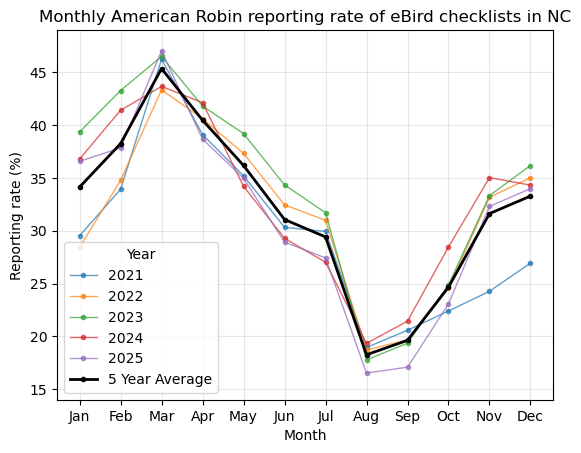

In [80]:
# plot a line for each year
for year, year_data in monthly_robins.groupby("year"):
    year_data = year_data.sort_values("month")
    plt.plot("month", "reporting_rate", data=year_data, marker=".", linewidth=1, alpha=0.7, label=str(year))

# plot the average over 5 years
average = monthly_robins.groupby("month")["reporting_rate"].mean()
average.plot(label="5 Year Average", marker=".", linewidth=2, alpha=1, color="black")

plt.xticks([1,2,3,4,5,6,7,8,9,10,11,12], 
           ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
plt.ylim(14, 49)
plt.xlabel("Month")
plt.ylabel("Reporting rate (%)")
plt.title("Monthly American Robin reporting rate of eBird checklists in NC")
plt.legend(title="Year")
plt.grid(alpha=0.3)
plt.show()

<Axes: xlabel='month', ylabel='reporting_rate'>

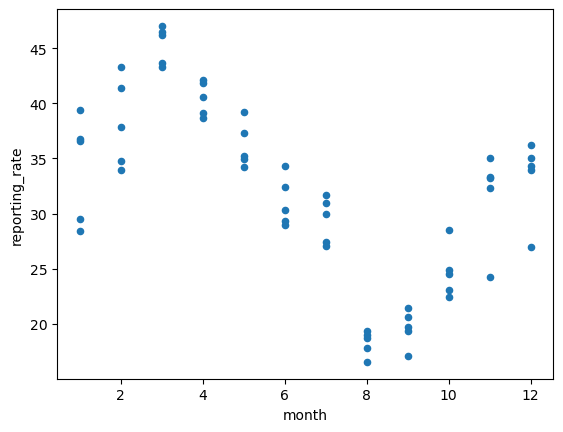

In [81]:
monthly_robins.plot(kind="scatter", x="month", y="reporting_rate")

In [82]:
# lets check that the number of checklists per month corresponds with the reporting rate
# ie it's less of a bias
# gives context, doesn't guarantee no bias
# total checklists bar graph
plt.bar(monthly_robins["month"])
plt.show()



TypeError: bar() missing 1 required positional argument: 'height'

In [ ]:
# other plot ideas
# separate 5 year average
# total # of checklists (should be similar shape to reporting rate)
# seasonal bar chart --> directly shows if spring is most popular
# weeks instead of months

Results
Clearly march has the highest
Why is Aug is the lowest?